# 1.0 SNR — 누설 지점(POI) 찾기

## 이 노트북이 답하는 질문

파형은 33,172 샘플이다. 그중 **어느 시점이 비밀과 관련된 정보를 흘리는가?**

`scalib.metrics.SNR` 은 시점마다 **신호대잡음비**를 계산해 그 질문에 답한다.
여기서 얻은 지점(POI, Point Of Interest)은 이후 모든 노트북의 출발점이다 —
CPA 는 그 근처에서 상관 봉우리를 찾고, 프로파일링은 그 지점만 골라 모델을 세운다.

| | |
|---|---|
| 입력 | `traces/scalib_dataset.h5` 의 `/explore` (랜덤 키·랜덤 평문 5,000장) |
| 출력 | `nb_output/poi.npz` — 바이트별 POI. 4.x 프로파일링 노트북이 읽는다 |
| 하드웨어 | 불필요 |

## SNR 이 무엇인가

파형의 한 시점 \(j\) 를 보자. 중간값 \(v\)(예: SBox 출력 한 바이트)가 값마다 다른 전력을
쓴다면, \(v\) 로 트레이스를 묶었을 때 **묶음마다 평균이 달라진다.**

$$
\mathrm{SNR}_j = \frac{\mathrm{Var}_v\left[\ \mathbb{E}[\ l_j \mid v\ ]\ \right]}
                      {\mathbb{E}_v\left[\ \mathrm{Var}[\ l_j \mid v\ ]\ \right]}
$$

- 분자 = **신호**: 클래스별 평균이 서로 얼마나 벌어져 있는가
- 분모 = **잡음**: 같은 클래스 안에서 값이 얼마나 흩어져 있는가

SNR 이 크면 그 시점은 중간값에 대해 말이 많다는 뜻이다. 0 에 가까우면 무관하다.

> SNR 은 **누설의 위치와 세기**를 알려줄 뿐 키를 복구하지 않는다.
> 키 복구는 3.0 CPA 이후의 노트북이 한다.

## 진행 순서

| 단계 | 내용 |
|:----:|------|
| 1 | 데이터 적재 |
| 2 | 라벨 만들기 — 무엇을 "중간값" 으로 볼 것인가 |
| 3 | `SNR` API 규약과 실행 |
| 4 | 결과 해석 — 16바이트의 POI |
| 5 | 클래스 정의를 바꿔 보기 (값 256 vs 해밍 가중치 9) |
| 6 | 트레이스 수에 따른 안정성 |
| 7 | POI 저장 |

---
## 1. 데이터 적재

`/explore` 는 키와 평문이 **둘 다 랜덤**이다. 그래서 1라운드 SBox 출력이 256 값을
고루 돌며, 클래스별 표본이 균형 있게 모인다 — SNR 추정에 필요한 조건이다.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling    4000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


파형   : (5000, 33172) int16
평문   : (5000, 16)  키: (5000, 16)
샘플/사이클: 4 → AES 전체 8293 사이클


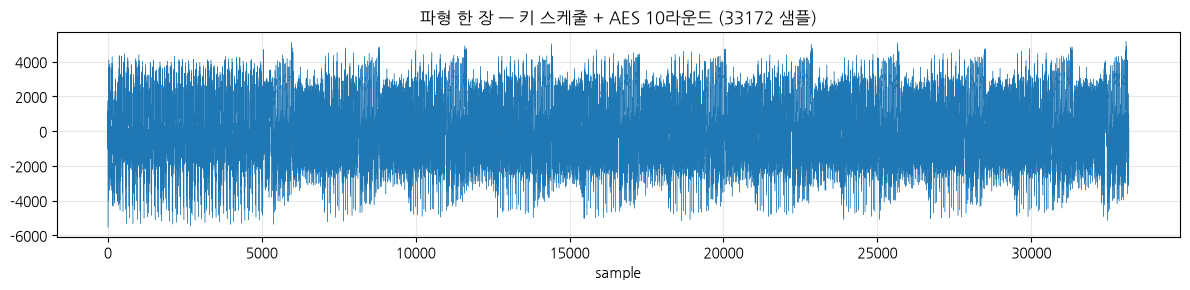

In [2]:
d = load_group("explore")
traces, pt, key = d["t"], d["p"], d["k"]
n, ns = traces.shape

print("파형   :", traces.shape, traces.dtype)
print("평문   :", pt.shape, " 키:", key.shape)
print("샘플/사이클:", d["attrs"]["adc_mul"], "→ AES 전체 %d 사이클" % (ns // d["attrs"]["adc_mul"]))

plt.figure(figsize=(12, 3))
plt.plot(traces[0], lw=0.3)
plt.title("파형 한 장 — 키 스케줄 + AES 10라운드 (%d 샘플)" % ns)
plt.xlabel("sample"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 2. 라벨 만들기

SNR 은 "무엇에 대한" 신호대잡음비인지를 **라벨**로 지정받는다. 라벨을 무엇으로 두느냐가
곧 "어떤 중간값의 누설을 찾는가" 이다.

여기서는 **1라운드 SBox 출력**을 본다.

$$ y_i = \mathrm{SBOX}[\ p_i \oplus k_i\ ] \qquad (i = 0..15) $$

이 값을 고르는 이유는 두 가지다.

1. **비선형**이다. XOR 만 거친 값(\(p \oplus k\))은 키 추측이 틀려도 누설이 비슷하게 보여
   구분이 잘 안 된다. S-box 를 통과하면 한 비트만 틀려도 출력이 크게 달라진다.
2. **바이트 단위로 분리**된다. 평문 한 바이트와 키 한 바이트에만 의존하므로 키를 16조각으로
   나누어 공략할 수 있다.

`sbox_out()` 은 `scalib_common.py` 에 정의되어 있다(정의를 한 곳에 두기 위함).

In [3]:
# 정답 키를 알고 있으므로 중간값을 그대로 계산할 수 있다.
# (공격 상황이 아니라 "누설이 어디 있는가" 를 보는 진단이므로 정당하다.
#  실제 공격에서는 키를 모르니 3.0 CPA 처럼 추측을 돌린다.)
y = sbox_out(pt, key)            # (n, 16) uint8 — 1라운드 SBox 출력
labels = y.astype(np.uint16)     # SNR 은 (n, nv) 2차원 uint16 을 요구한다

print("중간값 y :", y.shape, y.dtype)
print("바이트 0 의 값 분포: 최소 %d 최대 %d, 서로 다른 값 %d 개"
      % (y[:, 0].min(), y[:, 0].max(), len(np.unique(y[:, 0]))))
print("클래스당 평균 표본 수: %.1f 장" % (n / 256))

중간값 y : (5000, 16) uint8
바이트 0 의 값 분포: 최소 0 최대 255, 서로 다른 값 256 개
클래스당 평균 표본 수: 19.5 장


---
## 3. `SNR` API

| 단계 | 코드 | 역할 |
|:----:|------|------|
| 생성 | `snr = SNR(nc=256)` | 클래스 개수를 정한다 |
| 누적 | `snr.fit_u(traces, x)` | 여러 번 호출해 누적할 수 있다 (대용량용) |
| 결과 | `snr.get_snr()` | shape `(nv, ns)` 의 SNR 배열 |

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 파형(`traces`)은 어디서나 `(n, ns)` `int16` 이다.


`nv` 는 **동시에 볼 변수의 개수**다. 여기서는 16바이트를 한 번에 넣어 `(16, ns)` 를 받는다.
바이트마다 따로 돌리는 것보다 훨씬 빠르다 — 파형을 한 번만 훑기 때문이다.

In [4]:
from scalib.metrics import SNR
import time

t0 = time.time()
snr = SNR(nc=256)                 # SBox 출력은 0..255 의 256 클래스
snr.fit_u(traces, labels)         # (n, 16) 라벨 → 16개 변수를 한 번에
snr_val = snr.get_snr()           # (16, ns)
print("계산 %.1f 초 → %s" % (time.time() - t0, snr_val.shape))

# NaN 은 표본이 없는 클래스가 있을 때 나온다. 여기서는 5,000장/256클래스라
# 드물지만, 안전하게 0 으로 바꿔 최댓값 탐색에 영향이 없게 한다.
snr_val = np.nan_to_num(snr_val)

계산 0.2 초 → (16, 33172)


---
## 4. 결과 — 16바이트의 누설 지점

바이트마다 SNR 이 가장 큰 시점이 그 바이트의 POI 다.

In [5]:
poi = snr_val.argmax(axis=1)          # 바이트별 최대 지점
peak = snr_val.max(axis=1)

print("바이트  POI(sample)   최대 SNR   해당 사이클")
for i in range(AES_BLOCK):
    print("  %2d      %6d       %6.3f      %6.0f"
          % (i, poi[i], peak[i], poi[i] / d["attrs"]["adc_mul"]))
print()
print("POI 구간: %d ~ %d (폭 %d 샘플)" % (poi.min(), poi.max(), poi.max() - poi.min()))

바이트  POI(sample)   최대 SNR   해당 사이클
   0        6045        1.102        1511
   1        6277        1.039        1569
   2        6509        1.036        1627
   3        6741        1.020        1685
   4        6097        1.111        1524
   5        6329        1.048        1582
   6        6561        1.067        1640
   7        6793        1.039        1698
   8        6149        1.061        1537
   9        6381        1.066        1595
  10        6613        1.082        1653
  11        6845        0.998        1711
  12        6201        1.139        1550
  13        6433        1.064        1608
  14        6665        1.005        1666
  15        6897        1.049        1724

POI 구간: 6045 ~ 6897 (폭 852 샘플)


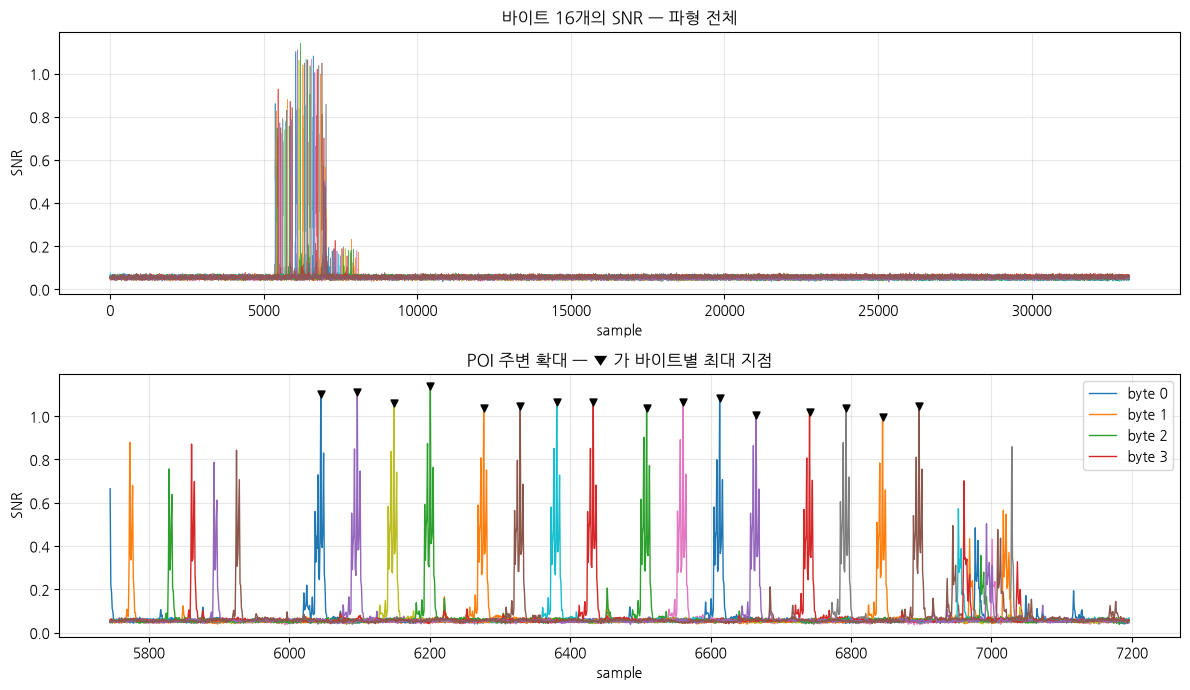

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# (1) 전체 구간에서 16바이트 SNR 을 겹쳐 그린다.
for i in range(AES_BLOCK):
    axes[0].plot(snr_val[i], lw=0.5, alpha=0.8)
axes[0].set_title("바이트 16개의 SNR — 파형 전체")
axes[0].set_xlabel("sample"); axes[0].set_ylabel("SNR")

# (2) POI 주변만 확대. 바이트별 봉우리가 순서대로 늘어서는지 본다.
lo, hi = max(0, poi.min() - 300), min(ns, poi.max() + 300)
for i in range(AES_BLOCK):
    axes[1].plot(range(lo, hi), snr_val[i, lo:hi], lw=1.0, label="byte %d" % i if i < 4 else None)
axes[1].scatter(poi, peak, marker="v", color="k", zorder=5, s=25)
axes[1].set_title("POI 주변 확대 — ▼ 가 바이트별 최대 지점")
axes[1].set_xlabel("sample"); axes[1].set_ylabel("SNR"); axes[1].legend(loc="upper right")

for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

### 대조군 — 의미 없는 라벨은 어떻게 나오는가

SNR 값이 "크다" 는 것은 상대적이다. 기준을 잡기 위해 **무작위 라벨**로 같은 계산을 돌린다.
중간값과 무관한 라벨이므로 신호가 없어야 하고, 남는 것은 추정 오차뿐이다.
이것이 이 데이터·이 장수에서의 **잡음 바닥**이다.

In [7]:
rng = np.random.RandomState(0)
snr_null = SNR(nc=256)
snr_null.fit_u(traces, rng.randint(0, 256, (n, 1)).astype(np.uint16))
null_val = np.nan_to_num(snr_null.get_snr()[0])

print("무작위 라벨 SNR 최댓값 : %.4f   ← 잡음 바닥" % null_val.max())
print("실제 라벨   SNR 최댓값 : %.4f   (바닥의 %.1f 배)"
      % (peak.max(), peak.max() / null_val.max()))
print()
print("→ 바닥보다 뚜렷하게 큰 봉우리만 실제 누설로 본다.")

무작위 라벨 SNR 최댓값 : 0.0713   ← 잡음 바닥
실제 라벨   SNR 최댓값 : 1.1390   (바닥의 16.0 배)

→ 바닥보다 뚜렷하게 큰 봉우리만 실제 누설로 본다.


---
## 5. 클래스 정의를 바꿔 보기

라벨을 무엇으로 두느냐에 따라 SNR 이 달라진다. 자주 쓰는 두 가지를 비교한다.

| 라벨 | 클래스 수 | 뜻 |
|------|:--------:|-----|
| SBox 출력 값 | 256 | 값 자체가 다르면 다른 클래스 |
| SBox 출력의 **해밍 가중치** | 9 | 1비트 개수만 본다 (0~8) |

해밍 가중치는 클래스가 9개뿐이라 **클래스당 표본이 훨씬 많아** 적은 트레이스로도 안정적이다.
대신 값이 달라도 비트 수가 같으면 한 클래스로 묶여 정보를 잃는다.
어느 쪽이 큰지는 타겟의 실제 누설 형태에 달려 있다.

바이트   값(256클래스)     HW(9클래스)
   0       1.102 @  6045     0.891 @  6045
   1       1.039 @  6277     0.827 @  6277
   2       1.036 @  6509     0.825 @  6509
   3       1.020 @  6741     0.797 @  6741
   4       1.111 @  6097     0.852 @  6097
   5       1.048 @  6329     0.816 @  6329
   6       1.067 @  6561     0.838 @  6561
   7       1.039 @  6793     0.809 @  6793
   8       1.061 @  6149     0.838 @  6149
   9       1.066 @  6381     0.826 @  6381
  10       1.082 @  6613     0.849 @  6613
  11       0.998 @  6845     0.798 @  6845
  12       1.139 @  6201     0.888 @  6201
  13       1.064 @  6433     0.851 @  6433
  14       1.005 @  6665     0.788 @  6665
  15       1.049 @  6897     0.860 @  6897


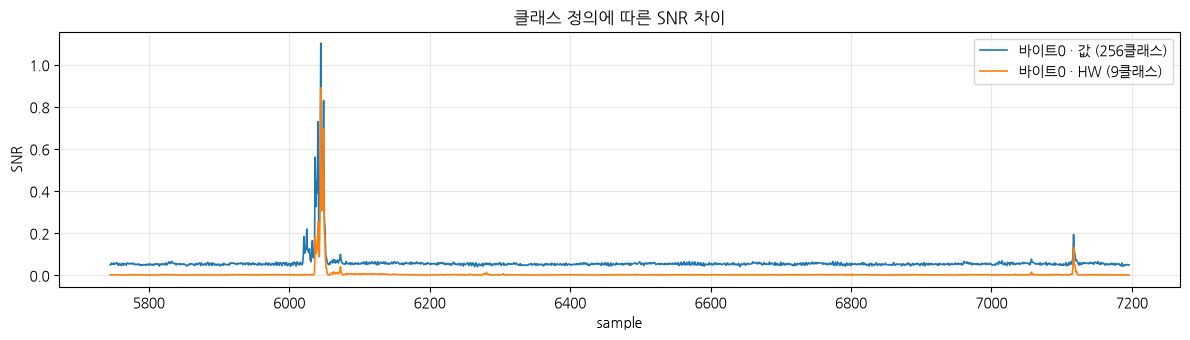

In [8]:
snr_hw = SNR(nc=9)
snr_hw.fit_u(traces, HW[y].astype(np.uint16))
hw_val = np.nan_to_num(snr_hw.get_snr())

print("바이트   값(256클래스)     HW(9클래스)")
for i in range(AES_BLOCK):
    print("  %2d      %6.3f @%6d    %6.3f @%6d"
          % (i, snr_val[i].max(), snr_val[i].argmax(),
             hw_val[i].max(), hw_val[i].argmax()))

plt.figure(figsize=(12, 3.5))
plt.plot(range(lo, hi), snr_val[0, lo:hi], lw=1.2, label="바이트0 · 값 (256클래스)")
plt.plot(range(lo, hi), hw_val[0, lo:hi], lw=1.2, label="바이트0 · HW (9클래스)")
plt.title("클래스 정의에 따른 SNR 차이"); plt.xlabel("sample"); plt.ylabel("SNR")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 6. 트레이스 수에 따른 안정성

SNR 은 **추정값**이다. 트레이스가 적으면 신호가 없어도 우연히 값이 커진다
(클래스당 표본이 적어 평균이 흔들리기 때문). 얼마나 모아야 믿을 만한지 본다.

In [9]:
subsets = [250, 500, 1000, 2000, n]
print("장수     바이트0 최대SNR   무작위라벨 최대SNR   비(신호/바닥)")
for m in subsets:
    s1 = SNR(nc=256); s1.fit_u(traces[:m], labels[:m, :1])
    v1 = np.nan_to_num(s1.get_snr()[0]).max()
    s0 = SNR(nc=256); s0.fit_u(traces[:m], rng.randint(0, 256, (m, 1)).astype(np.uint16))
    v0 = np.nan_to_num(s0.get_snr()[0]).max()
    print("%6d   %10.4f      %12.4f      %6.1f 배" % (m, v1, v0, v1 / v0))
print()
print("장수가 적으면 무작위 라벨의 SNR 도 커진다 — 그만큼 '봉우리' 를 믿기 어렵다.")

장수     바이트0 최대SNR   무작위라벨 최대SNR   비(신호/바닥)


   250       5.1354            3.2349         1.6 배
   500       2.9567            1.3843         2.1 배
  1000       1.7393            0.5058         3.4 배
  2000       1.3097            0.2041         6.4 배


  5000       1.1016            0.0730        15.1 배

장수가 적으면 무작위 라벨의 SNR 도 커진다 — 그만큼 '봉우리' 를 믿기 어렵다.


---
## 7. POI 저장

4.x 프로파일링 노트북은 파형 전체가 아니라 **POI 주변 몇십 샘플**만 쓴다.
33,172 샘플 전체로 LDA 를 돌리면 계산이 무겁고 오히려 정확도가 떨어지기 때문이다.

여기서 찾은 POI 를 저장해 그 노트북들이 다시 계산하지 않게 한다.

In [10]:
from pathlib import Path

OUT = Path("nb_output"); OUT.mkdir(exist_ok=True)
POI_PATH = OUT / "poi.npz"

# 바이트마다 POI 를 중심으로 창을 잡는다. 폭은 넉넉히 두되,
# 이웃 바이트의 봉우리까지 삼키지 않을 정도로 한다.
HALF = 20
poi_windows = np.stack([np.arange(p - HALF, p + HALF + 1) for p in poi])
poi_windows = np.clip(poi_windows, 0, ns - 1)

np.savez_compressed(
    POI_PATH,
    poi=poi,                     # (16,)   바이트별 최대 지점
    peak_snr=peak,               # (16,)   그때의 SNR
    windows=poi_windows,         # (16, 2*HALF+1) 창 인덱스
    snr=snr_val.astype(np.float32),   # (16, ns) 전체 곡선 (다른 노트북이 그림에 쓴다)
    noise_floor=null_val.max(),
    n_traces=n,
)
print("저장:", POI_PATH, "(%.1f KB)" % (POI_PATH.stat().st_size / 1e3))
print("창 크기: 바이트당 %d 샘플" % poi_windows.shape[1])

저장: nb_output/poi.npz (1780.1 KB)
창 크기: 바이트당 41 샘플


---
## 8. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 시점별 신호대잡음비로 **누설 위치**를 찾는다 (키 복구 아님) |
| API | `SNR(nc)` → `fit_u(traces, x)` → `get_snr()` |
| `traces` | `(n, ns)` `int16` |
| `x` | `(n, nv)` `uint16` — **2차원**. `Ttest` 와 다르다 |
| 결과 | `(nv, ns)` — 변수마다 한 줄 |
| 판단 기준 | 무작위 라벨로 잰 **잡음 바닥**과 비교한다 |
| 산출물 | `nb_output/poi.npz` — 4.x 가 읽는다 |

### 실패 시 점검

1. `ValueError: The classes array has N dimensions` → 라벨을 `(n, nv)` 로 만든다.
2. SNR 이 전 구간에서 바닥과 구분되지 않는다 → 트레이스를 늘리거나, 라벨(중간값) 정의가
   타겟 구현과 맞는지 본다. 이 타겟은 tiny-AES-c 의 1라운드 SBox 출력이 맞다.
3. 결과에 `NaN` 이 많다 → 표본이 없는 클래스가 있다는 뜻. 장수를 늘린다.

다음: `1.1.Quantizer.ipynb` — SCALib 이 요구하는 `int16` 로 파형을 옮기는 방법.